In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Проверяем формат столбцов

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата',as_index=False)['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


In [8]:
grouped_df.shape

(205, 2)

Нарисуйте график продаж у `grouped_df`

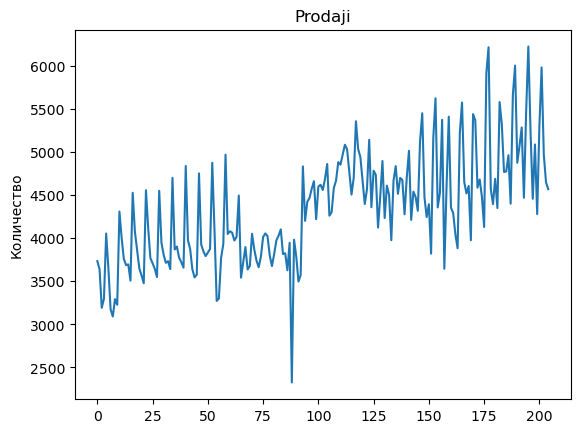

In [9]:
plt.plot(grouped_df['Количество'])
plt.title('Prodaji')
plt.ylabel('Количество')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Со временем продажи растут, пики и спады повторяются с примерно одинаковым интервалом, возможна недельная сезонность. В начале колебания умеренные, но со временем идут резкие скачки. В апреле виден спад, возможно из-за отсутствия продаж или сбоя

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
df.sort_values('Количество', ascending=False).head(1)

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
df[(df['Склад']==3) & (df['Дата'].between('2018-06-01', '2018-08-31'))&(df['Дата'].dt.day_name()=='Wednesday')].groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [12]:
dz= pd.read_excel("weather.xlsx")

In [13]:
dz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Местное время в Астане  1918 non-null   object 
 1   T                       1918 non-null   float64
 2   Po                      1918 non-null   float64
 3   P                       1918 non-null   float64
 4   Pa                      1915 non-null   float64
 5   U                       1917 non-null   float64
 6   DD                      1918 non-null   object 
 7   Ff                      1918 non-null   int64  
 8   ff10                    15 non-null     float64
 9   ff3                     51 non-null     float64
 10  N                       1916 non-null   object 
 11  WW                      1918 non-null   object 
 12  W1                      689 non-null    object 
 13  W2                      689 non-null    object 
 14  Tn                      240 non-null    

In [14]:
dz.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3,12.0,NaN,NaN,NaN,NaN


In [15]:
weather = dz[['Местное время в Астане', 'T']]

In [16]:
weather.head()

,Местное время в Астане,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [17]:
weather['datetime'] = pd.to_datetime(weather['Местное время в Астане'])
weather['date'] = weather['datetime'].dt.date
weather_daily=weather.groupby('date',as_index=False)['T'].mean()

/var/folders/vv/kxl00nn50tb3db4l3z00fqhh0000gn/T/ipykernel_1278/304186612.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  weather['datetime'] = pd.to_datetime(weather['Местное время в Астане'])
/var/folders/vv/kxl00nn50tb3db4l3z00fqhh0000gn/T/ipykernel_1278/304186612.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather['datetime'] = pd.to_datetime(weather['Местное время в Астане'])
/var/folders/vv/kxl00nn50tb3db4l3z00fqhh0000gn/T/ipykernel_1278/304186612.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [18]:
weather_daily.head()

,date,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [19]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date
weather_daily['date'] = pd.to_datetime(weather_daily['date']).dt.date
group=grouped_df.merge(weather_daily,left_on='Дата',right_on='date', how='left')

In [20]:
group1=group.drop(columns=['date'])

In [21]:
group1.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


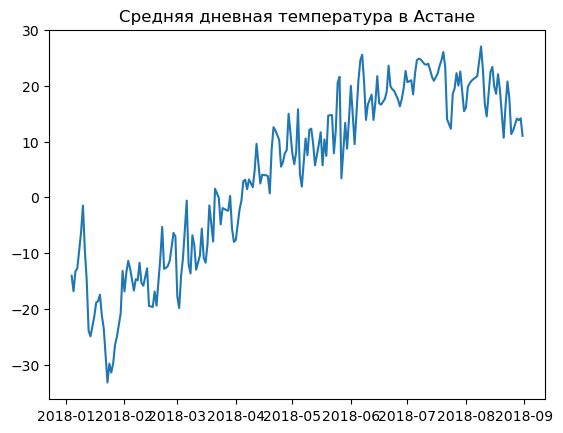

In [22]:
plt.plot(group1['Дата'],group1['T'])
plt.title('Средняя дневная температура в Астане')
plt.show()

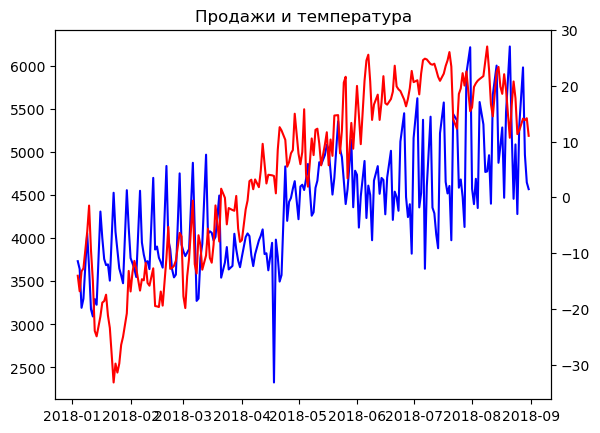

In [29]:
fig, ax1 = plt.subplots()
ax1.plot(group1['Дата'], group1['Количество'], color='blue')
ax2 = ax1.twinx()
ax2.plot(group1['Дата'], group1['T'], color='red')
plt.title('Продажи и температура')
plt.show()